# Visualization

In [14]:
import pandas as pd
import matplotlib.pyplot as plt

# Load your results
df_leak = pd.read_csv("../RESULTS/2B_SEGMENTS.csv")
df_proper = pd.read_csv("../RESULTS/2A_SEGMENTS.csv")


In [17]:
df_proper.columns

Index(['C', 'gamma', 'percentile', 'patient', 'record', 'n_windows',
       'n_seizure_windows', 'record_length', 'threshold', 'k', 'roc_auc', 'ap',
       'seg_accuracy', 'seg_specificity', 'seg_sensitivity', 'seg_precision',
       'seg_f1', 'tp', 'fp', 'fn'],
      dtype='object')

In [19]:
df_proper

,C,gamma,percentile,patient,record,n_windows,n_seizure_windows,record_length,threshold,k,roc_auc,ap,seg_accuracy,seg_specificity,seg_sensitivity,seg_precision,seg_f1,tp,fp,fn
0,10,0.001,10,chb01,chb01_03,1437,16,3600.0,-0.181511,6,0.980779,0.639859,0.987474,0.991555,0.625000,0.454545,0.526316,10,12,6
1,10,0.001,10,chb01,chb01_04,1437,11,3600.0,-0.118274,6,0.992732,0.680595,0.981211,0.982468,0.818182,0.264706,0.400000,9,25,2
2,10,0.001,10,chb01,chb01_15,1437,16,3600.0,0.032343,6,0.724842,0.065227,0.967293,0.976777,0.125000,0.057143,0.078431,2,33,14
3,10,0.001,10,chb01,chb01_16,1437,21,3600.0,-0.169998,6,0.993375,0.599980,0.987474,0.989407,0.857143,0.545455,0.666667,18,15,3
4,10,0.001,10,chb01,chb01_18,1437,37,3600.0,-0.324774,6,0.999035,0.968623,0.994433,0.997857,0.864865,0.914286,0.888889,32,3,5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
133,10,0.001,10,chb24,chb24_13,1437,6,3600.0,0.885554,3,0.892034,0.181971,0.995825,0.999301,0.166667,0.500000,0.250000,1,1,5
134,10,0.001,10,chb24,chb24_14,1437,11,3600.0,0.570956,3,0.947342,0.121375,0.981907,0.987377,0.272727,0.142857,0.187500,3,18,8
135,10,0.001,10,chb24,chb24_15,1437,7,3600.0,0.626751,2,0.860240,0.591640,0.995129,0.997902,0.428571,0.500000,0.461538,3,3,4
136,10,0.001,10,chb24,chb24_17,1437,27,3600.0,-0.756272,8,0.903336,0.287022,0.981211,1.000000,0.000000,NaN,NaN,0,0,27


In [21]:
metrics = [
    "roc_auc",
    "ap",
    "seg_accuracy",
    "seg_specificity",
    "seg_sensitivity",
    "seg_precision",
    "seg_f1",
]

proper_patient = (
    df_proper
    .groupby("patient")[metrics]
    .mean()
    .reset_index()
)

proper_patient = proper_patient.rename(columns={"ap": "auprc"})

In [31]:
df_leak.columns

Index(['config', 'C', 'gamma', 'percentile', 'patient', 'use_all_files',
       'n_train', 'n_test', 'test_pos', 'roc_auc', 'auprc', 'baseline_auprc',
       'seg_accuracy', 'seg_specificity', 'seg_sensitivity', 'seg_precision',
       'seg_f1', 'tn', 'fp', 'fn', 'tp'],
      dtype='object')

In [35]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import wilcoxon


# ======================================================
# Select leakage configuration
# ======================================================

df_leak_sel = df_leak[
    df_leak["use_all_files"] == True
].copy()


# keep only comparable columns

metrics = [
    "roc_auc",
    "auprc",
    "seg_accuracy",
    "seg_specificity",
    "seg_sensitivity",
    "seg_precision",
    "seg_f1",
]


leak_patient = df_leak_sel[
    ["patient"] + metrics
]


In [36]:
# ======================================================
# Merge leakage vs proper
# ======================================================

comparison = leak_patient.merge(
    proper_patient,
    on="patient",
    suffixes=("_leak", "_proper")
)


print(comparison)
print("patients compared:", len(comparison))



Empty DataFrame
Columns: [patient, roc_auc_leak, auprc_leak, seg_accuracy_leak, seg_specificity_leak, seg_sensitivity_leak, seg_precision_leak, seg_f1_leak, roc_auc_proper, auprc_proper, seg_accuracy_proper, seg_specificity_proper, seg_sensitivity_proper, seg_precision_proper, seg_f1_proper]
Index: []
patients compared: 0


In [38]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import wilcoxon


# ==========================================================
# 1. Prepare comparable data
# ==========================================================

metrics = [
    "roc_auc",
    "auprc",
    "seg_accuracy",
    "seg_specificity",
    "seg_sensitivity",
    "seg_precision",
    "seg_f1",
]


# leakage dataframe
leak_patient = df_leak[
    ["patient"] + metrics
].copy()


# proper dataframe
proper_patient_comp = proper_patient[
    ["patient"] + metrics
].copy()


# merge
comparison = leak_patient.merge(
    proper_patient_comp,
    on="patient",
    suffixes=("_leak", "_proper")
)


print(comparison)
print("\nPatients compared:", len(comparison))



   patient  roc_auc_leak  auprc_leak  seg_accuracy_leak  seg_specificity_leak  \
0    chb01      0.998043    0.911039           0.987435              0.989328   
1    chb02      0.996865    0.885714           0.975460              0.974922   
2    chb03      0.988952    0.641136           0.974155              0.976768   
3    chb04      0.988238    0.654856           0.957627              0.958525   
4    chb05      0.995826    0.900090           0.986092              0.988522   
5    chb06      0.913598    0.250842           0.995975              0.996238   
6    chb07      0.978786    0.671819           0.987265              0.989167   
7    chb08      0.974400    0.765940           0.972184              0.985337   
8    chb09      0.936669    0.884159           0.997099              0.998538   
9    chb10      0.986938    0.875565           0.995538              0.996998   
10   chb11      0.993328    0.961503           0.990050              0.997297   
11   chb12      0.962019    


===== Summary =====
            Metric  Leakage mean  Leakage SD  Proper mean  Proper SD  \
0          roc_auc        0.9773      0.0338       0.8814     0.0899   
1            auprc        0.7641      0.2053       0.3977     0.2261   
2     seg_accuracy        0.9826      0.0165       0.9565     0.0450   
3  seg_specificity        0.9855      0.0153       0.9687     0.0429   
4  seg_sensitivity        0.8294      0.1378       0.4591     0.1755   
5    seg_precision        0.6024      0.2636       0.3709     0.2350   
6           seg_f1        0.6647      0.2081       0.3591     0.1852   

   Mean difference  Median difference  Wilcoxon p  
0           0.0959             0.0568         0.0  
1           0.3664             0.3617         0.0  
2           0.0261             0.0170         0.0  
3           0.0168             0.0107         0.0  
4           0.3702             0.3597         0.0  
5           0.2315             0.2004         0.0  
6           0.3056             0.2800 

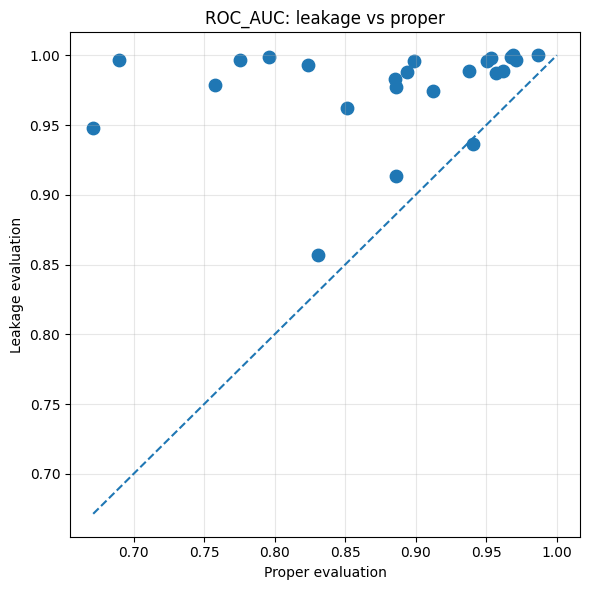

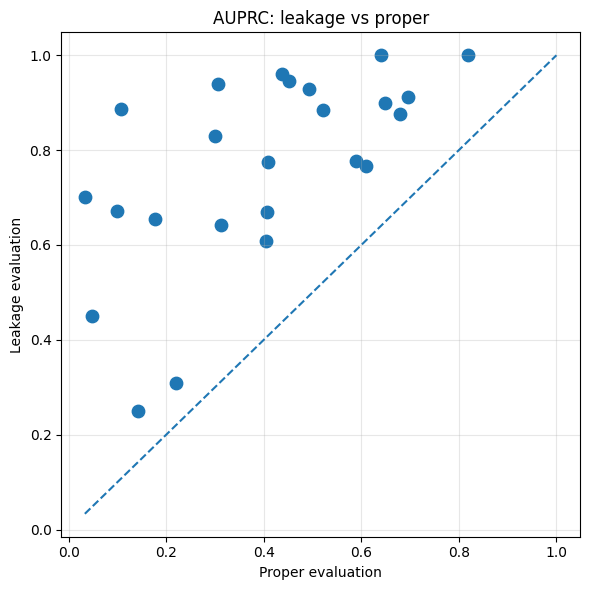

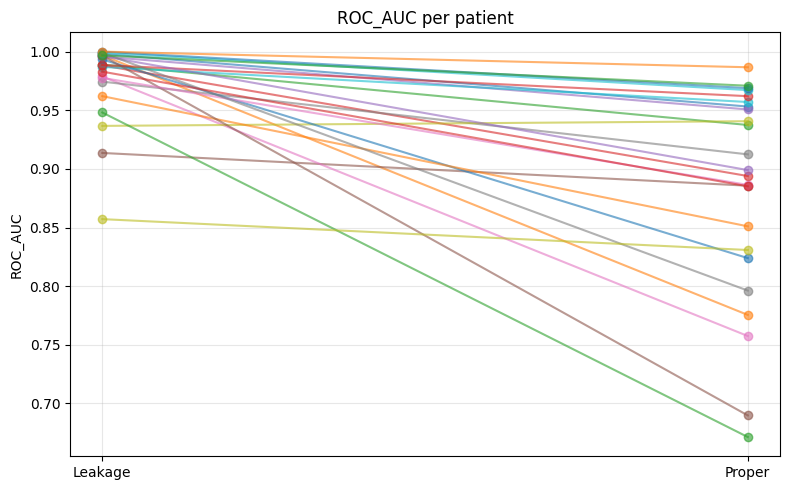

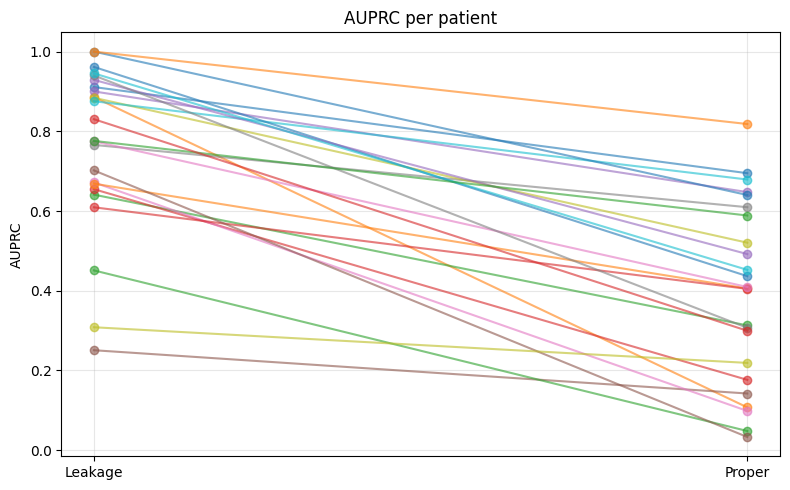

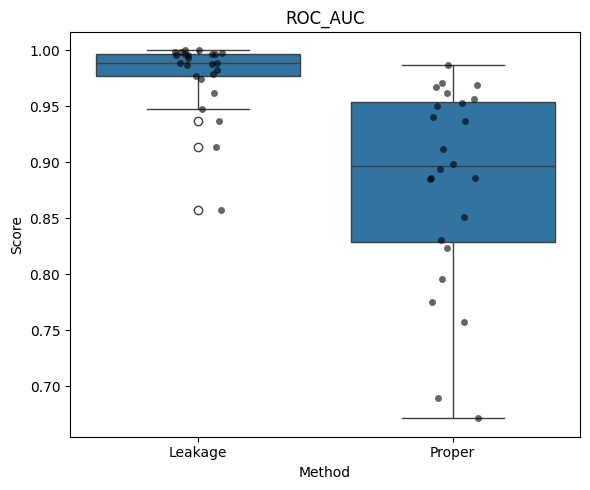

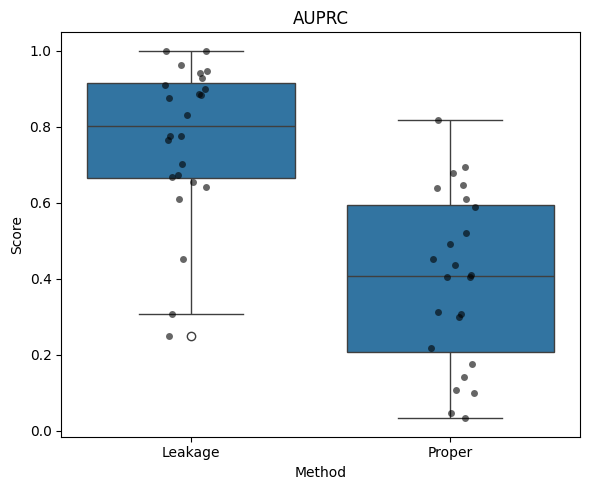

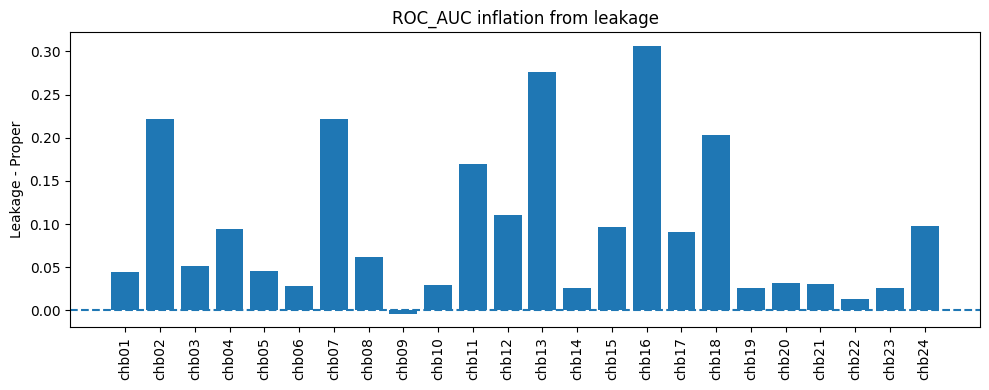

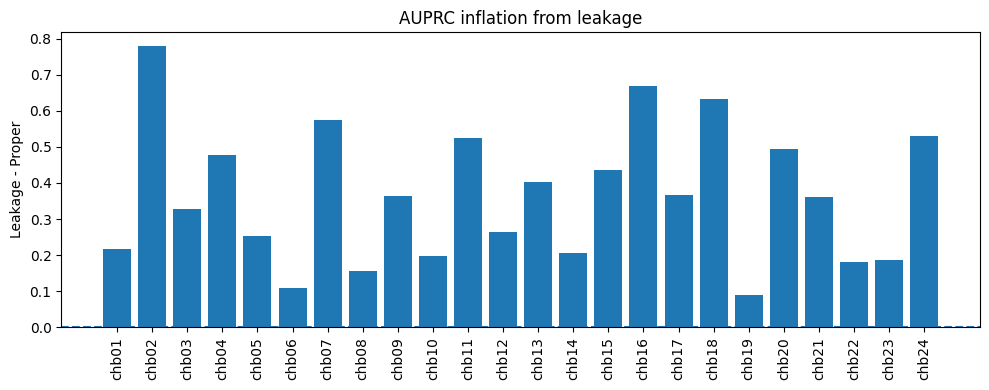

In [39]:


# ==========================================================
# 2. Summary table
# ==========================================================

summary = []

for m in metrics:

    leak = comparison[f"{m}_leak"]
    proper = comparison[f"{m}_proper"]

    stat, p = wilcoxon(
        leak,
        proper
    )

    summary.append({
        "Metric": m,
        "Leakage mean": leak.mean(),
        "Leakage SD": leak.std(),
        "Proper mean": proper.mean(),
        "Proper SD": proper.std(),
        "Mean difference": (leak - proper).mean(),
        "Median difference": (leak - proper).median(),
        "Wilcoxon p": p
    })


summary = pd.DataFrame(summary)

print("\n===== Summary =====")
print(summary.round(4))



# ==========================================================
# 3. Scatter plots
#    Leakage vs Proper
# ==========================================================

for metric in ["roc_auc", "auprc"]:

    plt.figure(figsize=(6,6))

    plt.scatter(
        comparison[f"{metric}_proper"],
        comparison[f"{metric}_leak"],
        s=80
    )


    lims = [
        min(
            comparison[f"{metric}_proper"].min(),
            comparison[f"{metric}_leak"].min()
        ),
        max(
            comparison[f"{metric}_proper"].max(),
            comparison[f"{metric}_leak"].max()
        )
    ]

    plt.plot(
        lims,
        lims,
        "--"
    )


    plt.xlabel("Proper evaluation")
    plt.ylabel("Leakage evaluation")
    plt.title(f"{metric.upper()}: leakage vs proper")

    plt.grid(alpha=0.3)

    plt.tight_layout()
    plt.show()



# ==========================================================
# 4. Paired patient lines
# ==========================================================

for metric in ["roc_auc", "auprc"]:

    plt.figure(figsize=(8,5))


    for _, row in comparison.iterrows():

        plt.plot(
            ["Leakage", "Proper"],
            [
                row[f"{metric}_leak"],
                row[f"{metric}_proper"]
            ],
            marker="o",
            alpha=0.6
        )


    plt.ylabel(metric.upper())
    plt.title(
        f"{metric.upper()} per patient"
    )

    plt.grid(alpha=0.3)

    plt.tight_layout()
    plt.show()



# ==========================================================
# 5. Distribution comparison
# ==========================================================

for metric in ["roc_auc", "auprc"]:


    plot_df = pd.DataFrame({

        "Leakage":
        comparison[f"{metric}_leak"],

        "Proper":
        comparison[f"{metric}_proper"]

    })


    plot_df = plot_df.melt(
        var_name="Method",
        value_name="Score"
    )


    plt.figure(figsize=(6,5))


    sns.boxplot(
        data=plot_df,
        x="Method",
        y="Score"
    )

    sns.stripplot(
        data=plot_df,
        x="Method",
        y="Score",
        color="black",
        alpha=0.6
    )


    plt.title(metric.upper())

    plt.tight_layout()
    plt.show()



# ==========================================================
# 6. Leakage inflation per patient
# ==========================================================

for metric in ["roc_auc", "auprc"]:

    diff = (
        comparison[f"{metric}_leak"]
        -
        comparison[f"{metric}_proper"]
    )


    plt.figure(figsize=(10,4))


    plt.bar(
        comparison["patient"],
        diff
    )

    plt.axhline(
        0,
        linestyle="--"
    )


    plt.ylabel(
        "Leakage - Proper"
    )

    plt.title(
        f"{metric.upper()} inflation from leakage"
    )


    plt.xticks(
        rotation=90
    )

    plt.tight_layout()
    plt.show()

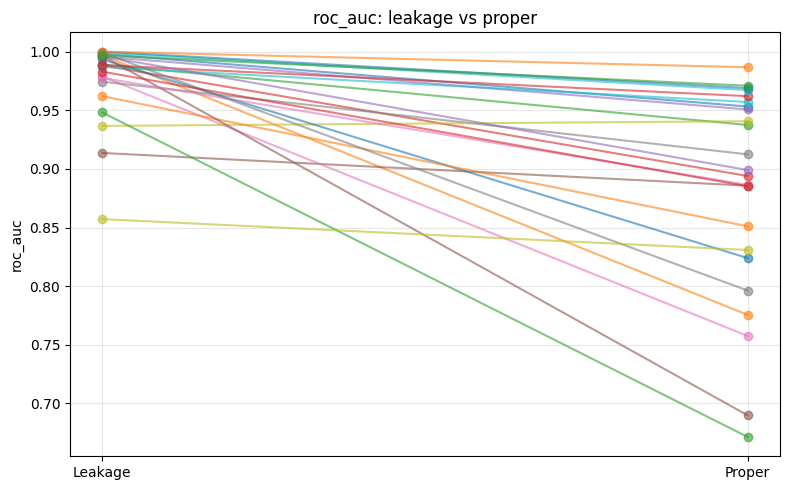

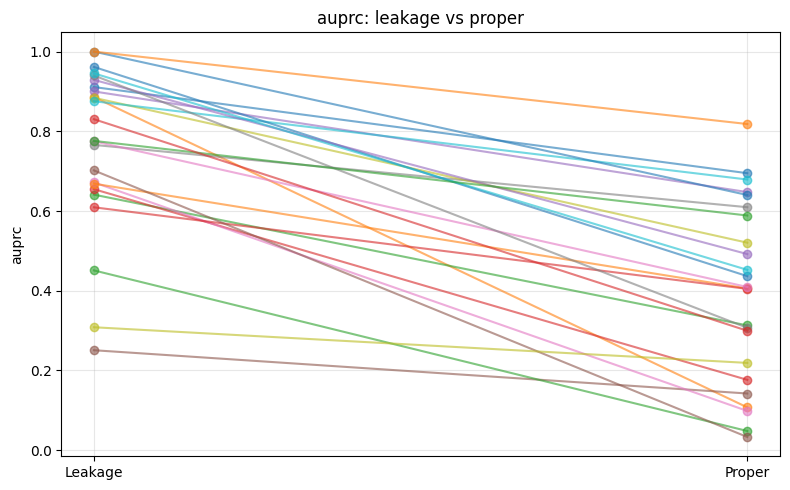

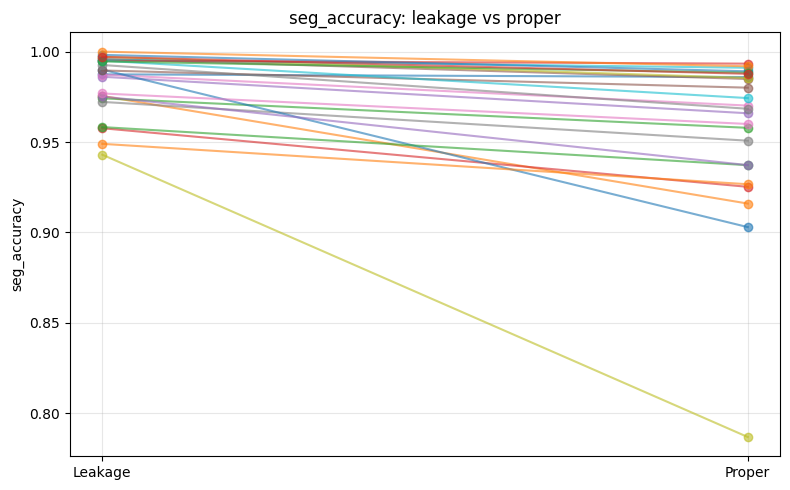

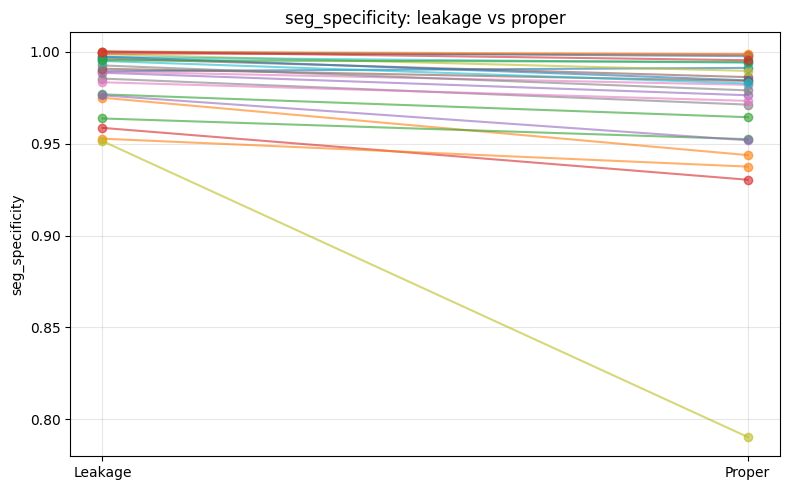

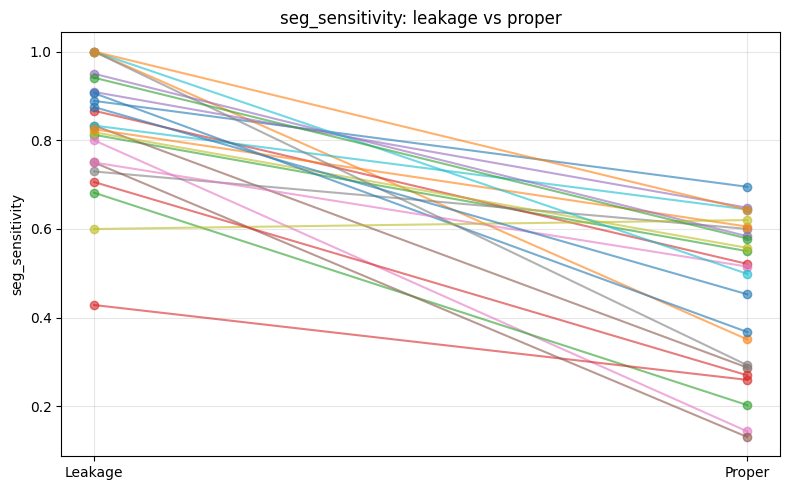

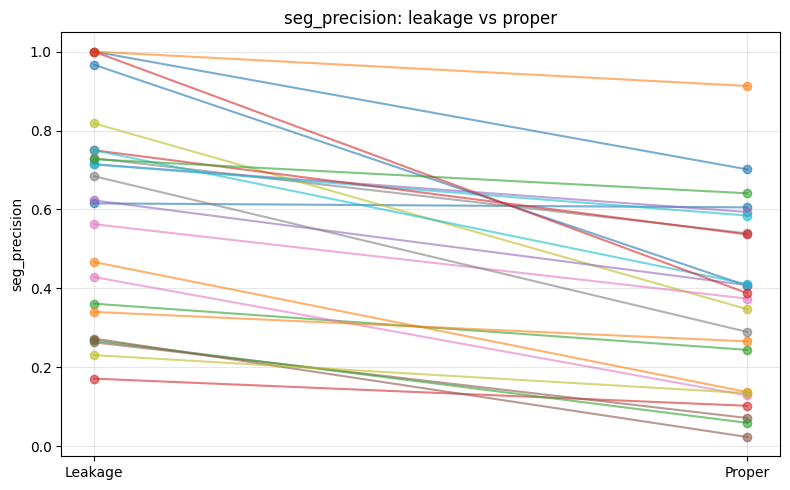

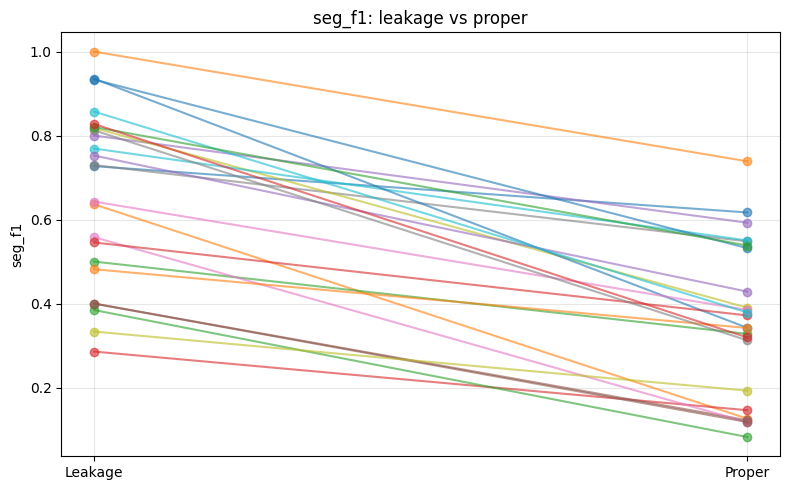

In [48]:
for metric in [
    "roc_auc",
    "auprc",
    "seg_accuracy",
    "seg_specificity",
    "seg_sensitivity",
    "seg_precision",
    "seg_f1"
]:

    plt.figure(figsize=(8,5))

    for _, row in comparison.iterrows():

        plt.plot(
            ["Leakage", "Proper"],
            [
                row[f"{metric}_leak"],
                row[f"{metric}_proper"]
            ],
            marker="o",
            alpha=0.6
        )

    plt.ylabel(metric)
    plt.title(f"{metric}: leakage vs proper")
    plt.grid(alpha=0.3)

    plt.tight_layout()
    plt.show()

In [41]:
from scipy.stats import wilcoxon
import pandas as pd
import numpy as np


metrics = [
    "roc_auc",
    "auprc",
    "seg_accuracy",
    "seg_specificity",
    "seg_sensitivity",
    "seg_precision",
    "seg_f1"
]


stats = []


for m in metrics:

    leakage = comparison[f"{m}_leak"]
    proper = comparison[f"{m}_proper"]

    # paired difference
    diff = leakage - proper

    stat, p = wilcoxon(
        leakage,
        proper,
        alternative="two-sided"
    )

    stats.append({
        "Metric": m,
        "Leakage mean": leakage.mean(),
        "Proper mean": proper.mean(),
        "Mean difference": diff.mean(),
        "Median difference": diff.median(),
        "Wilcoxon statistic": stat,
        "p-value": p
    })


stats = pd.DataFrame(stats)


# multiple comparison correction
from statsmodels.stats.multitest import multipletests

stats["p_adj"] = multipletests(
    stats["p-value"],
    method="fdr_bh"
)[1]


print(stats.round(4))

            Metric  Leakage mean  Proper mean  Mean difference  \
0          roc_auc        0.9773       0.8814           0.0959   
1            auprc        0.7641       0.3977           0.3664   
2     seg_accuracy        0.9826       0.9565           0.0261   
3  seg_specificity        0.9855       0.9687           0.0168   
4  seg_sensitivity        0.8294       0.4591           0.3702   
5    seg_precision        0.6024       0.3709           0.2315   
6           seg_f1        0.6647       0.3591           0.3056   

   Median difference  Wilcoxon statistic  p-value  p_adj  
0             0.0568                 1.0      0.0    0.0  
1             0.3617                 0.0      0.0    0.0  
2             0.0170                 0.0      0.0    0.0  
3             0.0107                 4.0      0.0    0.0  
4             0.3597                 1.0      0.0    0.0  
5             0.2004                 0.0      0.0    0.0  
6             0.2800                 0.0      0.0    0.0  

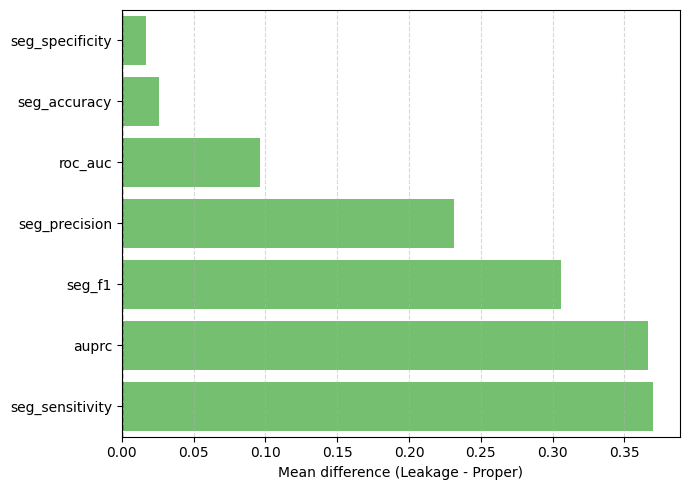

In [75]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(7,5))

sns.barplot(
    x=diff.values,
    y=diff.index,
    color=sns.color_palette("muted")[2]
)

plt.axvline(0, color="black", linestyle="--", linewidth=1)

# Grid
plt.grid(axis="x", linestyle="--", alpha=0.5)

plt.xlabel("Mean difference (Leakage - Proper)")
plt.ylabel("")

plt.tight_layout()
plt.show()

In [49]:
diff_df = comparison.set_index("patient")[
    [f"{m}_leak" for m in metrics]
].copy()

for m in metrics:
    diff_df[m] = (
        comparison[f"{m}_leak"].values -
        comparison[f"{m}_proper"].values
    )

diff_df = diff_df[metrics]

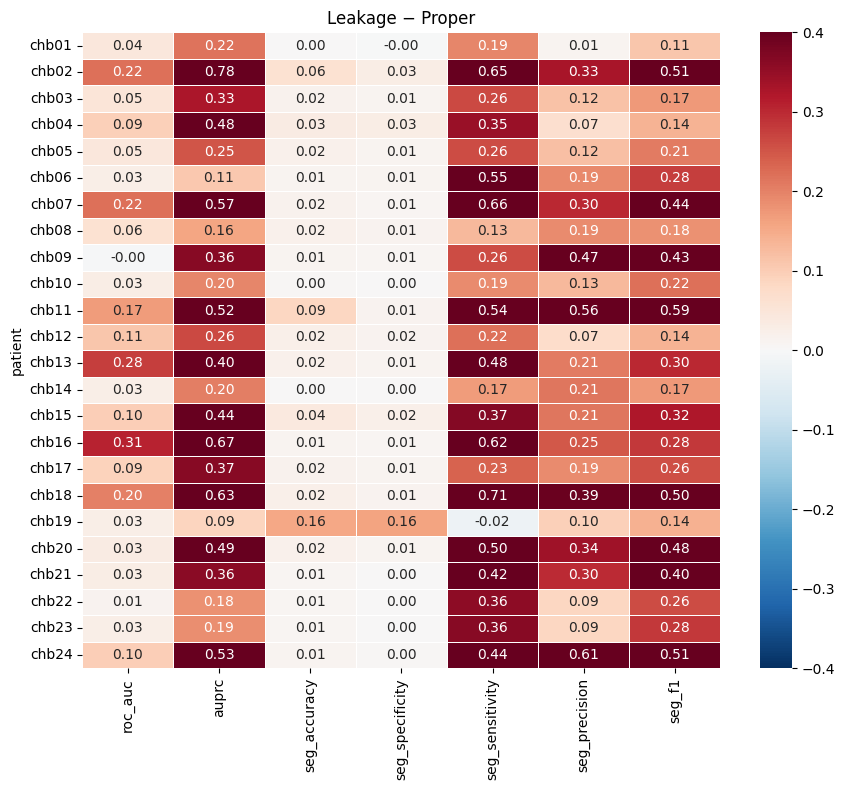

In [50]:
plt.figure(figsize=(9,8))

sns.heatmap(
    diff_df,
    annot=True,
    fmt=".2f",
    cmap="RdBu_r",
    center=0,
    linewidths=0.5,
    vmin=-0.4,
    vmax=0.4
)

plt.title("Leakage − Proper")
plt.tight_layout()
plt.show()

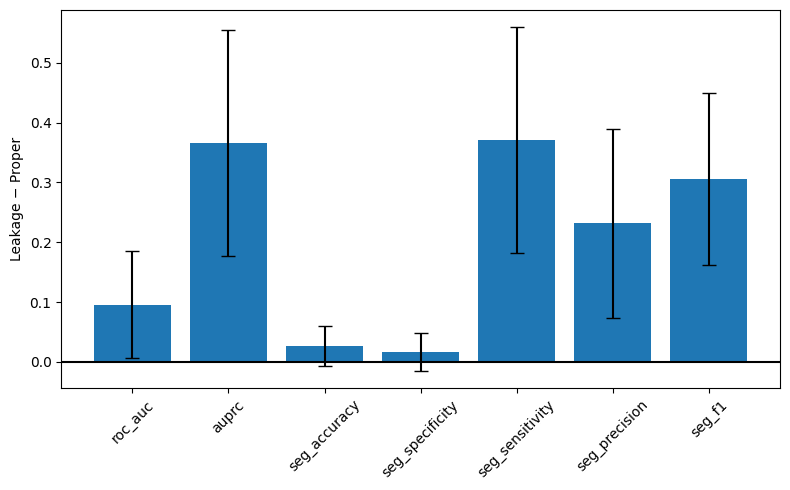

In [51]:
mean_diff = []
std_diff = []

for m in metrics:
    diff = comparison[f"{m}_leak"] - comparison[f"{m}_proper"]
    mean_diff.append(diff.mean())
    std_diff.append(diff.std())

plt.figure(figsize=(8,5))

plt.bar(metrics, mean_diff, yerr=std_diff, capsize=5)

plt.axhline(0, color="black")

plt.ylabel("Leakage − Proper")

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

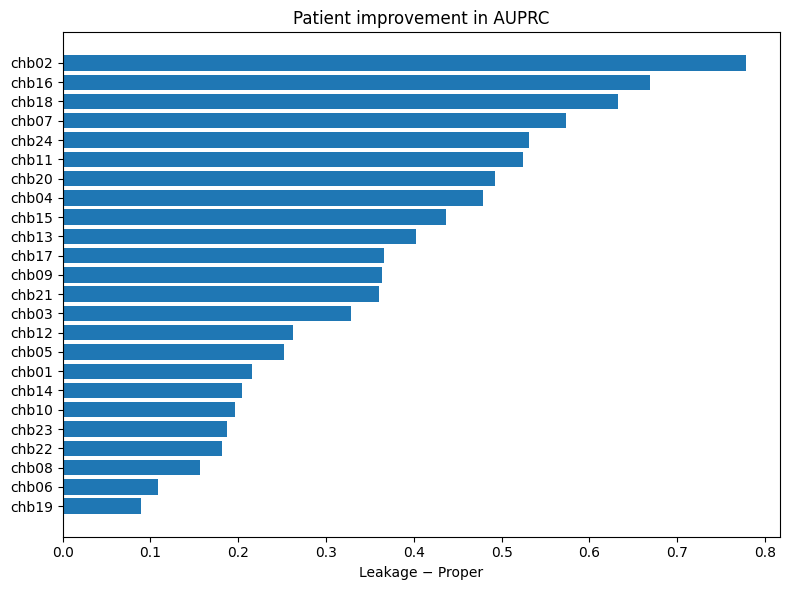

In [52]:
metric = "auprc"

diff = (
    comparison[["patient"]]
    .assign(
        diff=comparison[f"{metric}_leak"]
        - comparison[f"{metric}_proper"]
    )
    .sort_values("diff")
)

plt.figure(figsize=(8,6))

plt.barh(diff.patient, diff["diff"])

plt.xlabel("Leakage − Proper")
plt.title("Patient improvement in AUPRC")

plt.tight_layout()
plt.show()

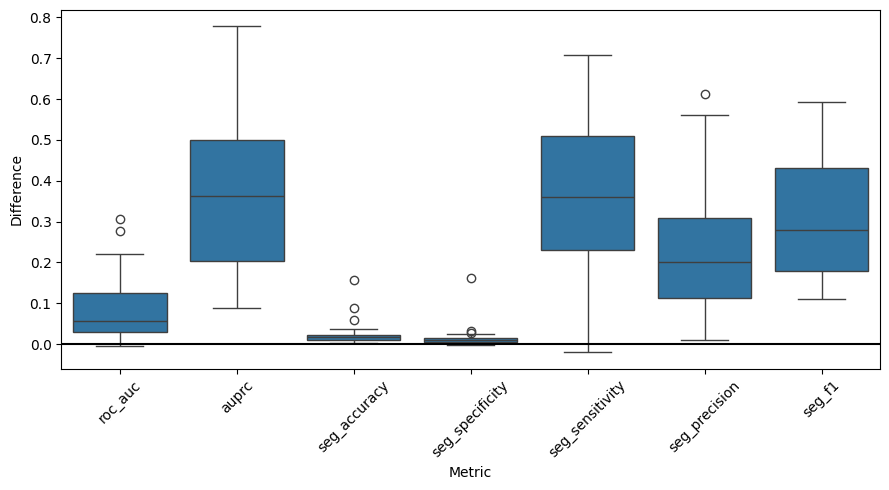

In [55]:
diff_df = pd.DataFrame()

for m in metrics:
    diff_df[m] = (
        comparison[f"{m}_leak"]
        - comparison[f"{m}_proper"]
    )

plot_df = diff_df.melt(
    var_name="Metric",
    value_name="Difference"
)

plt.figure(figsize=(9,5))

sns.boxplot(
    data=plot_df,
    x="Metric",
    y="Difference"
)

plt.axhline(0, color="black")

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

In [34]:


# ======================================================
# Summary table
# ======================================================

summary = []

for m in metrics:

    leak = comparison[f"{m}_leak"]
    proper = comparison[f"{m}_proper"]

    stat, p = wilcoxon(leak, proper)

    summary.append({
        "Metric": m,
        "Leakage mean": leak.mean(),
        "Proper mean": proper.mean(),
        "Leakage SD": leak.std(),
        "Proper SD": proper.std(),
        "Mean difference": (leak-proper).mean(),
        "Wilcoxon p": p
    })


summary = pd.DataFrame(summary)

print(summary.round(3))




            Metric  Leakage mean  Proper mean  Leakage SD  Proper SD  \
0          roc_auc           NaN          NaN         NaN        NaN   
1            auprc           NaN          NaN         NaN        NaN   
2     seg_accuracy           NaN          NaN         NaN        NaN   
3  seg_specificity           NaN          NaN         NaN        NaN   
4  seg_sensitivity           NaN          NaN         NaN        NaN   
5    seg_precision           NaN          NaN         NaN        NaN   
6           seg_f1           NaN          NaN         NaN        NaN   

   Mean difference  Wilcoxon p  
0              NaN         NaN  
1              NaN         NaN  
2              NaN         NaN  
3              NaN         NaN  
4              NaN         NaN  
5              NaN         NaN  
6              NaN         NaN  


In [ ]:

# ==========================================================
# Summary table
# ==========================================================

summary = []

for m in metrics:

    leak = comparison[f"{m}_leak"]
    proper = comparison[f"{m}_proper"]

    try:
        _, p = wilcoxon(leak, proper)
    except:
        p = np.nan

    summary.append({
        "Metric": m,
        "Leakage mean": leak.mean(),
        "Leakage SD": leak.std(),
        "Proper mean": proper.mean(),
        "Proper SD": proper.std(),
        "Mean difference": (leak - proper).mean(),
        "Median difference": (leak - proper).median(),
        "Wilcoxon p": p
    })

summary = pd.DataFrame(summary)

print("\nSummary:")
print(summary.round(4))


# ==========================================================
# Scatter plots
# ==========================================================

for metric in ["roc_auc", "auprc"]:

    plt.figure(figsize=(6,6))

    plt.scatter(
        comparison[f"{metric}_proper"],
        comparison[f"{metric}_leak"],
        alpha=0.75
    )

    lims = [
        min(plt.xlim()[0], plt.ylim()[0]),
        max(plt.xlim()[1], plt.ylim()[1])
    ]

    plt.plot(lims, lims, "k--")

    plt.xlim(lims)
    plt.ylim(lims)

    plt.xlabel("Proper evaluation")
    plt.ylabel("Leakage evaluation")
    plt.title(metric.upper())

    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()


# ==========================================================
# Histogram of paired differences
# ==========================================================

for metric in ["roc_auc", "auprc"]:

    diff = (
        comparison[f"{metric}_leak"]
        - comparison[f"{metric}_proper"]
    )

    plt.figure(figsize=(6,4))

    plt.hist(diff, bins=20)

    plt.axvline(0, color="red", linestyle="--")

    plt.xlabel("Leakage − Proper")
    plt.ylabel("Number of records")
    plt.title(metric.upper())

    plt.tight_layout()
    plt.show()


# ==========================================================
# Patient-wise boxplots
# ==========================================================

for metric in ["roc_auc", "auprc"]:

    plot_df = comparison.melt(
        id_vars=["patient", "record"],
        value_vars=[
            f"{metric}_leak",
            f"{metric}_proper"
        ],
        var_name="Method",
        value_name="Score"
    )

    plot_df["Method"] = (
        plot_df["Method"]
        .str.replace(f"{metric}_", "")
    )

    plt.figure(figsize=(12,5))

    sns.boxplot(
        data=plot_df,
        x="patient",
        y="Score",
        hue="Method"
    )

    plt.xticks(rotation=90)
    plt.title(metric.upper())

    plt.tight_layout()
    plt.show()


# ==========================================================
# Difference per patient
# ==========================================================

for metric in ["roc_auc", "auprc"]:

    patient_diff = (
        comparison
        .assign(
            diff=comparison[f"{metric}_leak"]
                 - comparison[f"{metric}_proper"]
        )
        .groupby("patient")["diff"]
        .mean()
        .sort_values()
    )

    plt.figure(figsize=(10,4))

    plt.bar(patient_diff.index, patient_diff.values)

    plt.axhline(0, color="black")

    plt.ylabel("Mean Leakage − Proper")
    plt.title(metric.upper())

    plt.xticks(rotation=90)

    plt.tight_layout()
    plt.show()

In [4]:
for col in ["C", "gamma", "percentile"]:
    vc = df[col].value_counts()
    print(f"\n{col}")
    print(f"Mode: {vc.index[0]}")
    print(f"Count: {vc.iloc[0]} / {len(df)} ({100*vc.iloc[0]/len(df):.1f}%)")


C
Mode: 10.0
Count: 480 / 683 (70.3%)

gamma
Mode: 0.001
Count: 276 / 683 (40.4%)

percentile
Mode: 10
Count: 562 / 683 (82.3%)


In [5]:
for col in ["C", "gamma", "percentile"]:
    print(f"\n{col}")
    print(df[col].value_counts(normalize=True).sort_index())


C
C
0.1     0.184480
1.0     0.112738
10.0    0.702782
Name: proportion, dtype: float64

gamma
gamma
0.0001    0.260615
0.0010    0.404100
0.0100    0.335286
Name: proportion, dtype: float64

percentile
percentile
5     0.17716
10    0.82284
Name: proportion, dtype: float64


In [10]:
df['percentile'].mode()

0    10
Name: percentile, dtype: int64

# 1. Mean Performance per Configuration

In [10]:
summary = (
    df.groupby("config")
      .agg({
          "sensitivity":"mean",
          "precision":"mean",
          "f1":"mean",
          "FP/day":"mean",
          "mean_fold_ap":"mean",
          "mean_fold_roc_auc":"mean"
      })
)

print(summary.round(3))

        sensitivity  precision     f1  FP/day  mean_fold_ap  mean_fold_roc_auc
config                                                                        
A             0.471      0.273  0.289  17.184         0.340              0.873
B             0.510      0.294  0.333  13.712         0.372              0.883
C             0.528      0.324  0.353  16.961         0.381              0.882
D             0.484      0.270  0.301  16.362         0.351              0.876
E             0.477      0.231  0.270   6.752         0.334              0.878


# 2. Sensitivity per Configuration

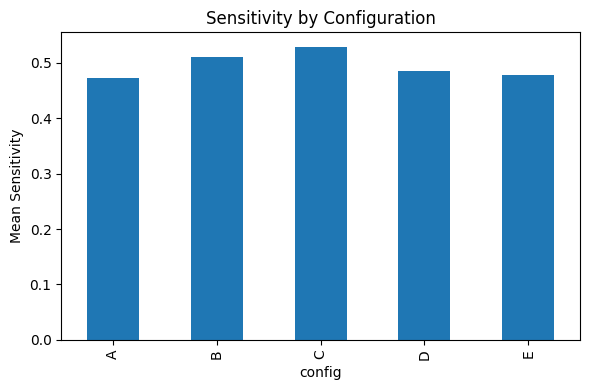

In [13]:
import matplotlib.pyplot as plt

config_summary = (
    df.groupby("config")["sensitivity"]
      .mean()
)

plt.figure(figsize=(6,4))
config_summary.plot(kind="bar")

plt.ylabel("Mean Sensitivity")
plt.title("Sensitivity by Configuration")

plt.tight_layout()
plt.show()

# 3. FP per Configuration

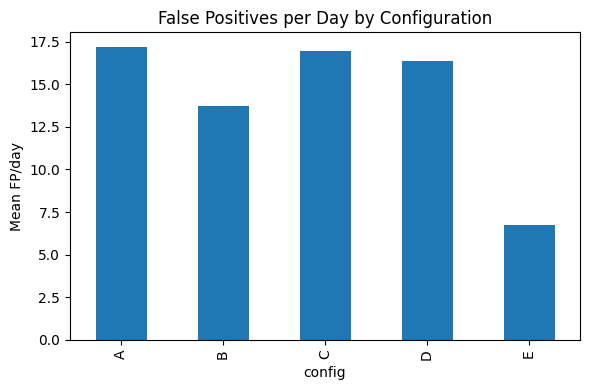

In [14]:
config_summary = (
    df.groupby("config")["FP/day"]
      .mean()
)

plt.figure(figsize=(6,4))
config_summary.plot(kind="bar")

plt.ylabel("Mean FP/day")
plt.title("False Positives per Day by Configuration")

plt.tight_layout()
plt.show()

# 4. Boxplot

<Figure size 800x500 with 0 Axes>

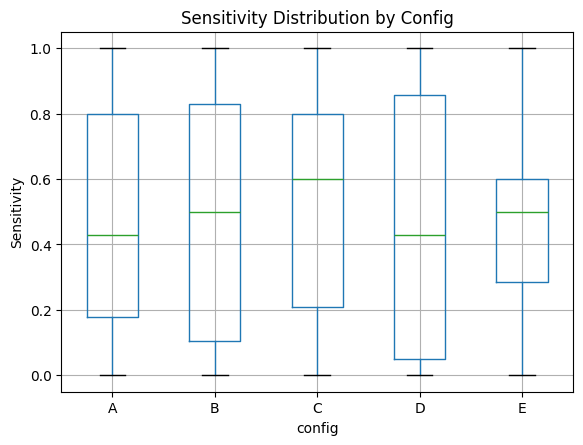

In [15]:
plt.figure(figsize=(8,5))

df.boxplot(
    column="sensitivity",
    by="config"
)

plt.title("Sensitivity Distribution by Config")
plt.suptitle("")

plt.ylabel("Sensitivity")

plt.show()

# 5. Scatter plot

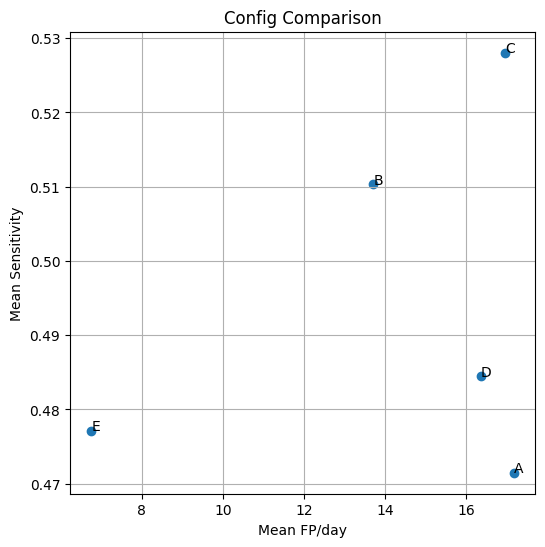

In [16]:
config_perf = (
    df.groupby("config")
      .agg({
          "sensitivity":"mean",
          "FP/day":"mean"
      })
      .reset_index()
)

plt.figure(figsize=(6,6))

plt.scatter(
    config_perf["FP/day"],
    config_perf["sensitivity"]
)

for _, row in config_perf.iterrows():
    plt.annotate(
        row["config"],
        (row["FP/day"], row["sensitivity"])
    )

plt.xlabel("Mean FP/day")
plt.ylabel("Mean Sensitivity")
plt.title("Config Comparison")

plt.grid(True)

plt.show()

# 6. Heatmap

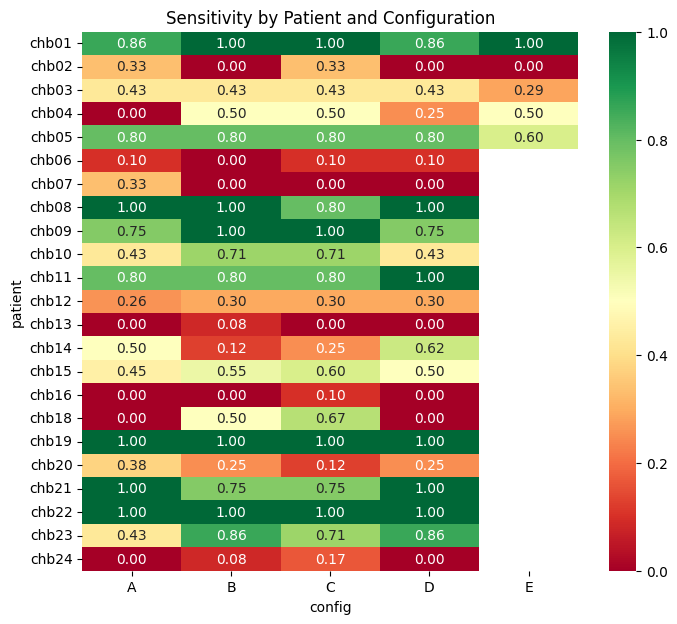

In [23]:
import seaborn as sns
import matplotlib.pyplot as plt

pivot = df.pivot(
    index="patient",
    columns="config",
    values="sensitivity"
)

plt.figure(figsize=(8,7))

sns.heatmap(
    pivot,
    annot=True,
    fmt=".2f",
    cmap="RdYlGn",
    vmin=0,
    vmax=1
)

plt.title("Sensitivity by Patient and Configuration")
plt.show()